# AI-Based Crop Rotation Recommendation System
### 1. Data Exploration & Preprocessing

**Dataset**: Kaggle Crop Recommendation Dataset (N, P, K, temperature, humidity, pH, rainfall -> crop)

Steps in this notebook:
1. Load and inspect the dataset
2. Basic EDA (distributions, correlations)
3. Add crop-family / rotation-rule metadata
4. Save cleaned data for model training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## 1. Load Dataset

Download `Crop_recommendation.csv` from Kaggle: search "Crop Recommendation Dataset" (by Atharva Ingle).
Place it in the `data/` folder before running this cell.

In [2]:
df = pd.read_csv('../data/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [4]:
print(df['label'].value_counts())
print(f"\nTotal unique crops: {df['label'].nunique()}")

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Total unique crops: 22


## 2. Exploratory Data Analysis

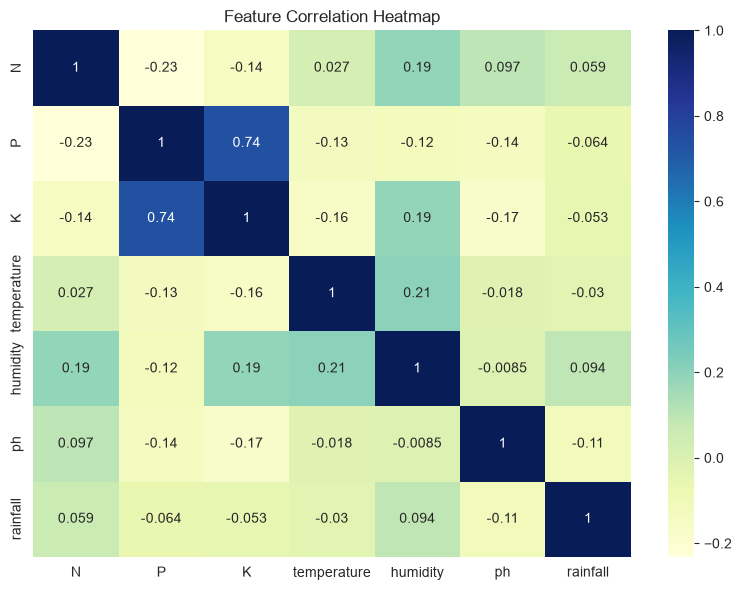

In [5]:
# Correlation heatmap of numeric features
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='YlGnBu')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../report/correlation_heatmap.png', dpi=150)
plt.show()

C:\Users\yashs\AppData\Local\Temp\ipykernel_15976\2458792809.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\yashs\AppData\Local\Temp\ipykernel_15976\2458792809.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\yashs\AppData\Local\Temp\ipykernel_15976\2458792809.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


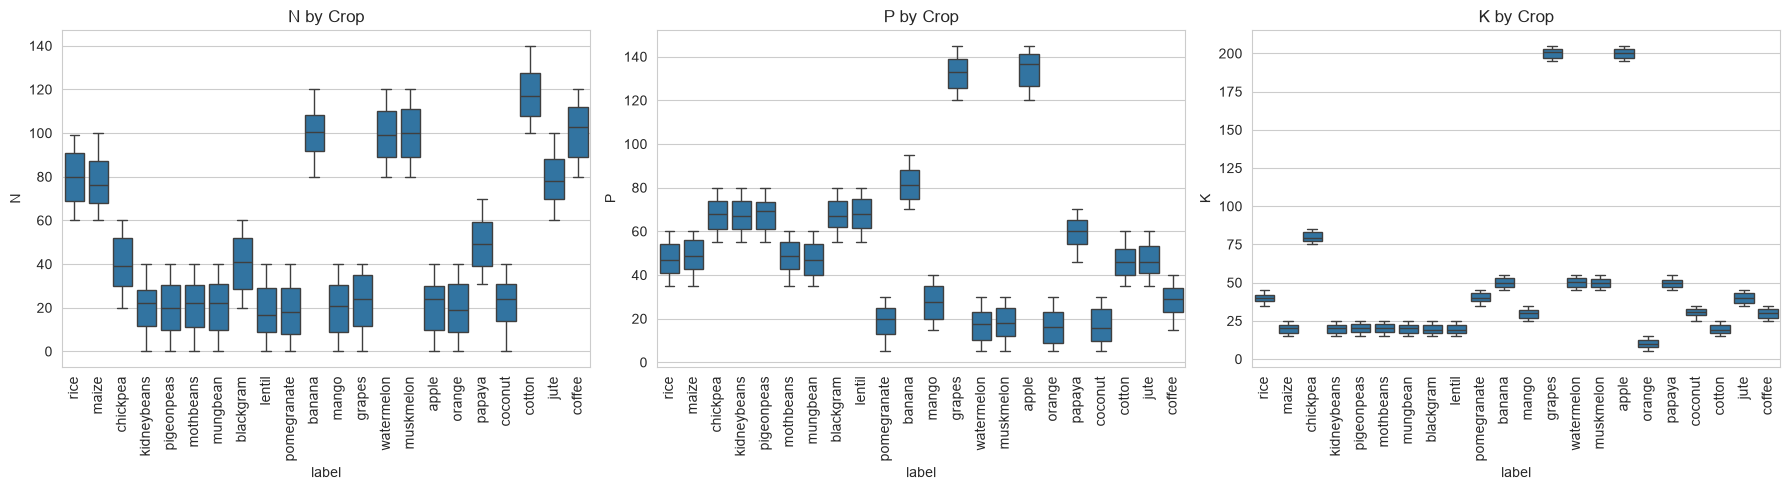

In [6]:
# Feature distributions by crop (example: N, P, K)
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, col in zip(axes, ['N', 'P', 'K']):
    sns.boxplot(data=df, x='label', y=col, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_title(f'{col} by Crop')
plt.tight_layout()
plt.savefig('../report/npk_by_crop.png', dpi=150)
plt.show()

## 3. Crop Rotation Domain Rules

This is the key addition that turns a plain crop-recommendation dataset into a **rotation** system.

We define:
- **Crop family** (for disease/pest cycle-breaking — avoid same family back-to-back)
- **Nitrogen behavior** (legumes fix nitrogen; heavy feeders like cereals deplete it)

Edit/expand this dictionary based on the actual crop labels in your dataset.

In [7]:
# Example structure -- expand this to cover every crop label in your dataset
crop_metadata = {
    'rice':        {'family': 'cereal',  'nitrogen_effect': 'depleting'},
    'maize':       {'family': 'cereal',  'nitrogen_effect': 'depleting'},
    'chickpea':    {'family': 'legume',  'nitrogen_effect': 'fixing'},
    'kidneybeans': {'family': 'legume',  'nitrogen_effect': 'fixing'},
    'pigeonpeas':  {'family': 'legume',  'nitrogen_effect': 'fixing'},
    'mothbeans':   {'family': 'legume',  'nitrogen_effect': 'fixing'},
    'mungbean':    {'family': 'legume',  'nitrogen_effect': 'fixing'},
    'blackgram':   {'family': 'legume',  'nitrogen_effect': 'fixing'},
    'lentil':      {'family': 'legume',  'nitrogen_effect': 'fixing'},
    'cotton':      {'family': 'fiber',   'nitrogen_effect': 'depleting'},
    'jute':        {'family': 'fiber',   'nitrogen_effect': 'neutral'},
    # TODO: fill in remaining crop labels from df['label'].unique()
}

print('Labels missing metadata:', set(df['label'].unique()) - set(crop_metadata.keys()))

Labels missing metadata: {'muskmelon', 'apple', 'pomegranate', 'watermelon', 'papaya', 'banana', 'coconut', 'orange', 'grapes', 'mango', 'coffee'}


## 4. Save Cleaned Data

In [8]:
df.to_csv('../data/crop_data_clean.csv', index=False)
print('Saved cleaned dataset.')

Saved cleaned dataset.
